In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
print("Data Preparation")

X, y = load_diabetes(return_X_y=True)
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of features: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data Preparation
Dataset shape: X=(442, 10), y=(442,)
Number of features: 10
Training set: 353 samples
Test set: 89 samples


In [3]:
print("Baseline OLS Model")

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

y_train_pred_ols = ols.predict(X_train_scaled)
y_test_pred_ols = ols.predict(X_test_scaled)

train_rmse_ols = np.sqrt(mean_squared_error(y_train, y_train_pred_ols))
test_rmse_ols = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
train_r2_ols = r2_score(y_train, y_train_pred_ols)
test_r2_ols = r2_score(y_test, y_test_pred_ols)

ols_coef = ols.coef_.copy()

print("OLS Model Results:")
print(f"Training RMSE: {train_rmse_ols:.4f}")
print(f"Test RMSE:     {test_rmse_ols:.4f}")
print(f"Training R²:   {train_r2_ols:.4f}")
print(f"Test R²:       {test_r2_ols:.4f}")

print("\nOLS Coefficients:")
for i, coef in enumerate(ols_coef):
    print(f"  Feature {i}: {coef:.4f}")

Baseline OLS Model
OLS Model Results:
Training RMSE: 53.5588
Test RMSE:     53.8534
Training R²:   0.5279
Test R²:       0.4526

OLS Coefficients:
  Feature 0: 1.7538
  Feature 1: -11.5118
  Feature 2: 25.6071
  Feature 3: 16.8289
  Feature 4: -44.4489
  Feature 5: 24.6410
  Feature 6: 7.6770
  Feature 7: 13.1388
  Feature 8: 35.1612
  Feature 9: 2.3514


In [7]:
# Ridge Regression
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_train_rmse = []
ridge_test_rmse = []
ridge_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)
    
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    
    ridge_coefs.append(ridge.coef_)

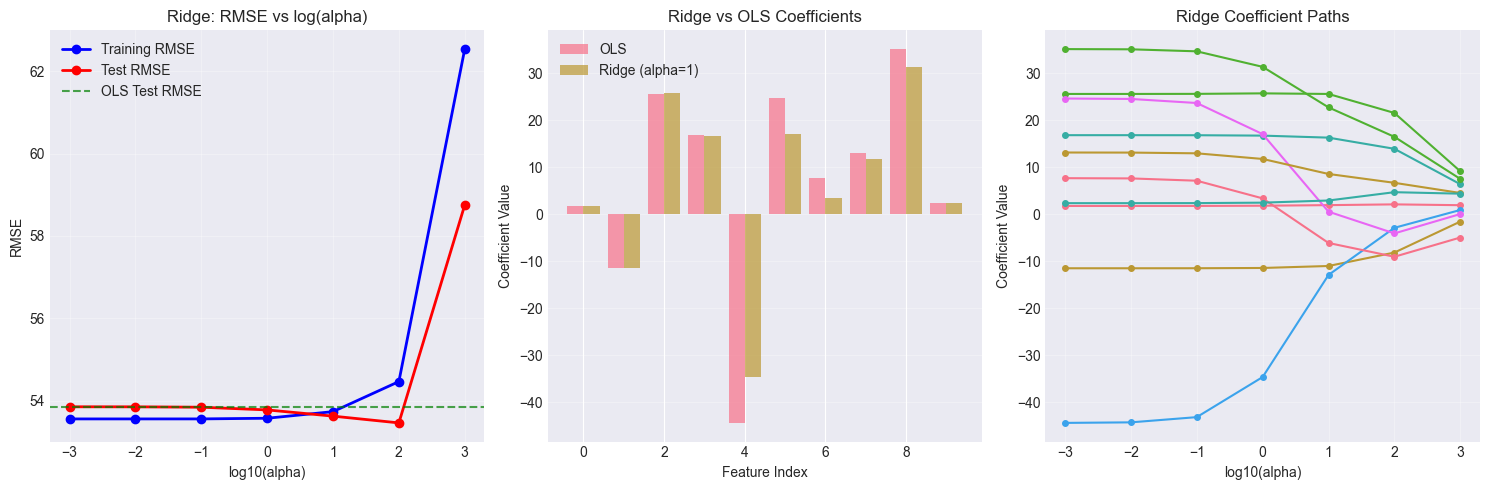

Ridge Regression Results:
Best alpha by test RMSE: 100
Minimum test RMSE: 53.4624
OLS test RMSE: 53.8534


In [8]:
# Training and test RMSE vs log(alpha)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(np.log10(alphas), ridge_train_rmse, 'b-o', label='Training RMSE', linewidth=2)
plt.plot(np.log10(alphas), ridge_test_rmse, 'r-o', label='Test RMSE', linewidth=2)
plt.axhline(y=test_rmse_ols, color='g', linestyle='--', label='OLS Test RMSE', alpha=0.7)
plt.xlabel('log10(alpha)')
plt.ylabel('RMSE')
plt.title('Ridge: RMSE vs log(alpha)')
plt.legend()
plt.grid(True, alpha=0.3)

# Compare Ridge coefficients to OLS
plt.subplot(1, 3, 2)
x_pos = np.arange(len(ols_coef))
plt.bar(x_pos - 0.2, ols_coef, width=0.4, label='OLS', alpha=0.7)
plt.bar(x_pos + 0.2, ridge_coefs[alphas.index(1)], width=0.4, label='Ridge (alpha=1)', alpha=0.7)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Ridge vs OLS Coefficients')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Ridge coefficient paths
plt.subplot(1, 3, 3)
ridge_coefs = np.array(ridge_coefs).T
for i in range(ridge_coefs.shape[0]):
    plt.plot(np.log10(alphas), ridge_coefs[i], '-o', label=f'Feature {i}', linewidth=1.5, markersize=4)
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Paths')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Ridge Regression Results:")
print(f"Best alpha by test RMSE: {alphas[np.argmin(ridge_test_rmse)]}")
print(f"Minimum test RMSE: {min(ridge_test_rmse):.4f}")
print(f"OLS test RMSE: {test_rmse_ols:.4f}")


In [6]:
# Lasso regression
lasso_train_rmse = []
lasso_test_rmse = []
lasso_coefs = []
non_zero_counts = []

fine_alphas = np.logspace(-4, 2, 50)

lasso_coefs_fine = []
for alpha in fine_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs_fine.append(lasso.coef_)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    
    y_train_pred = lasso.predict(X_train_scaled)
    y_test_pred = lasso.predict(X_test_scaled)
    
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    
    lasso_coefs.append(lasso.coef_)
    non_zero_counts.append(np.sum(lasso.coef_ != 0))

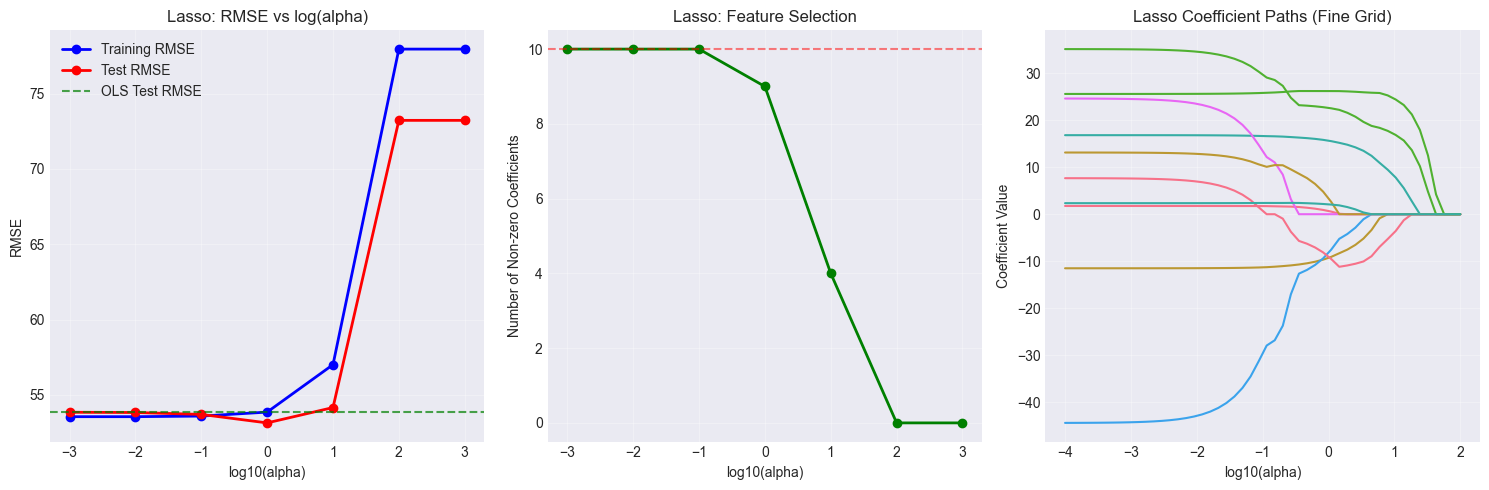

Lasso Regression Results:
Best alpha by test RMSE: 1
Minimum test RMSE: 53.1467
OLS test RMSE: 53.8534

Number of non-zero coefficients for different alphas:
  alpha=0.001: 10 non-zero coefficients
  alpha=0.01: 10 non-zero coefficients
  alpha=0.1: 10 non-zero coefficients
  alpha=1: 9 non-zero coefficients
  alpha=10: 4 non-zero coefficients
  alpha=100: 0 non-zero coefficients
  alpha=1000: 0 non-zero coefficients


In [9]:
# Training and test RMSE vs log(alpha)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(np.log10(alphas), lasso_train_rmse, 'b-o', label='Training RMSE', linewidth=2)
plt.plot(np.log10(alphas), lasso_test_rmse, 'r-o', label='Test RMSE', linewidth=2)
plt.axhline(y=test_rmse_ols, color='g', linestyle='--', label='OLS Test RMSE', alpha=0.7)
plt.xlabel('log10(alpha)')
plt.ylabel('RMSE')
plt.title('Lasso: RMSE vs log(alpha)')
plt.legend()
plt.grid(True, alpha=0.3)

# Number of non-zero coefficients vs alpha
plt.subplot(1, 3, 2)
plt.plot(np.log10(alphas), non_zero_counts, 'g-o', linewidth=2)
plt.xlabel('log10(alpha)')
plt.ylabel('Number of Non-zero Coefficients')
plt.title('Lasso: Feature Selection')
plt.grid(True, alpha=0.3)
plt.axhline(y=len(ols_coef), color='r', linestyle='--', alpha=0.5, label='All Features')

# Lasso coefficient paths
plt.subplot(1, 3, 3)
lasso_coefs_fine = np.array(lasso_coefs_fine).T
for i in range(lasso_coefs_fine.shape[0]):
    plt.plot(np.log10(fine_alphas), lasso_coefs_fine[i], '-', linewidth=1.5)
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths (Fine Grid)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Lasso Regression Results:")
print(f"Best alpha by test RMSE: {alphas[np.argmin(lasso_test_rmse)]}")
print(f"Minimum test RMSE: {min(lasso_test_rmse):.4f}")
print(f"OLS test RMSE: {test_rmse_ols:.4f}")
print("\nNumber of non-zero coefficients for different alphas:")
for alpha, count in zip(alphas, non_zero_counts):
    print(f"  alpha={alpha}: {count} non-zero coefficients")

In [10]:
print("Cross-validation with GridSearchCV")

param_grid = {'alpha': np.logspace(-4, 3, 50)}

cv = KFold(n_splits=10, shuffle=True, random_state=42)

print("Ridge Regression CV")
ridge_cv = GridSearchCV(Ridge(random_state=42), param_grid, 
                       cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_cv.best_params_['alpha']
ridge_best = Ridge(alpha=best_alpha_ridge, random_state=42)
ridge_best.fit(X_train_scaled, y_train)
y_test_pred_ridge = ridge_best.predict(X_test_scaled)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

print(f"Best alpha: {best_alpha_ridge:.6f}")
print(f"Test RMSE with best alpha: {test_rmse_ridge:.4f}")
print(f"CV RMSE score: {np.sqrt(-ridge_cv.best_score_):.4f}")

print("Lasso Regression CV")
lasso_cv = GridSearchCV(Lasso(max_iter=10000, random_state=42), param_grid, 
                       cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.best_params_['alpha']
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=42)
lasso_best.fit(X_train_scaled, y_train)
y_test_pred_lasso = lasso_best.predict(X_test_scaled)
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

print(f"Best alpha: {best_alpha_lasso:.6f}")
print(f"Test RMSE with best alpha: {test_rmse_lasso:.4f}")
print(f"CV RMSE score: {np.sqrt(-lasso_cv.best_score_):.4f}")

print(f"\nNumber of non-zero coefficients in best Lasso: {np.sum(lasso_best.coef_ != 0)}")

Cross-validation with GridSearchCV
Ridge Regression CV
Best alpha: 0.719686
Test RMSE with best alpha: 53.7935
CV RMSE score: 55.3697
Lasso Regression CV
Best alpha: 0.138950
Test RMSE with best alpha: 53.6884
CV RMSE score: 55.3653

Number of non-zero coefficients in best Lasso: 9


In [12]:
# # Bias-Variance Tradeoff

# n_repeats = 30
# alpha_range = np.logspace(-3, 3, 20)

# train_rmse_matrix = []
# test_rmse_matrix = []

# for repeat in range(n_repeats):
#     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
#         X, y, test_size=0.2, random_state=repeat)
    
#     scaler_temp = StandardScaler()
#     X_train_scaled_temp = scaler_temp.fit_transform(X_train_temp)
#     X_test_scaled_temp = scaler_temp.transform(X_test_temp)
    
#     train_rmse_repeat = []
#     test_rmse_repeat = []
    
#     for alpha in alpha_range:
#         ridge_temp = Ridge(alpha=alpha, random_state=repeat)
#         ridge_temp.fit(X_train_scaled_temp, y_train_temp)
        
#         y_train_pred_temp = ridge_temp.predict(X_train_scaled_temp)
#         y_test_pred_temp = ridge_temp.predict(X_test_scaled_temp)
        
#         train_rmse_repeat.append(np.sqrt(mean_squared_error(y_train_temp, y_train_pred_temp)))
#         test_rmse_repeat.append(np.sqrt(mean_squared_error(y_test_temp, y_test_pred_temp)))
    
#     train_rmse_matrix.append(train_rmse_repeat)
#     test_rmse_matrix.append(test_rmse_repeat)

# train_rmse_matrix = np.array(train_rmse_matrix)
# test_rmse_matrix = np.array(test_rmse_matrix)

# train_rmse_mean = np.mean(train_rmse_matrix, axis=0)
# test_rmse_mean = np.mean(test_rmse_matrix, axis=0)
# train_rmse_var = np.var(train_rmse_matrix, axis=0)
# test_rmse_var = np.var(test_rmse_matrix, axis=0)

In [1]:
# plt.figure(figsize=(12, 10))

# plt.subplot(2, 2, 1)
# plt.plot(np.log10(alpha_range), train_rmse_mean, 'b-', label='Train RMSE (mean)', linewidth=2)
# plt.plot(np.log10(alpha_range), test_rmse_mean, 'r-', label='Test RMSE (mean)', linewidth=2)
# plt.fill_between(np.log10(alpha_range), 
#                  train_rmse_mean - np.sqrt(train_rmse_var), 
#                  train_rmse_mean + np.sqrt(train_rmse_var), 
#                  alpha=0.3, color='blue', label='Train ± std')
# plt.fill_between(np.log10(alpha_range), 
#                  test_rmse_mean - np.sqrt(test_rmse_var), 
#                  test_rmse_mean + np.sqrt(test_rmse_var), 
#                  alpha=0.3, color='red', label='Test ± std')
# plt.xlabel('log10(alpha)')
# plt.ylabel('RMSE')
# plt.title('Bias-Variance Tradeoff: RMSE vs Regularization')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 2)
# plt.plot(np.log10(alpha_range), train_rmse_var, 'b-', label='Train RMSE variance', linewidth=2)
# plt.plot(np.log10(alpha_range), test_rmse_var, 'r-', label='Test RMSE variance', linewidth=2)
# plt.xlabel('log10(alpha)')
# plt.ylabel('Variance of RMSE')
# plt.title('Variance of RMSE across splits')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 3)
# bias_squared = (train_rmse_mean**2)
# plt.plot(np.log10(alpha_range), bias_squared, 'g-', label='Bias² (proxy)', linewidth=2)
# plt.plot(np.log10(alpha_range), test_rmse_var, 'r-', label='Variance', linewidth=2)
# plt.plot(np.log10(alpha_range), bias_squared + test_rmse_var, 'k--', label='Bias² + Variance', linewidth=2)
# plt.xlabel('log10(alpha)')
# plt.ylabel('Error components')
# plt.title('Bias-Variance Decomposition')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 2, 4)
# optimal_idx = np.argmin(test_rmse_mean)
# plt.axvline(x=np.log10(alpha_range[optimal_idx]), color='k', linestyle='--', 
#            label=f'Optimal alpha: {alpha_range[optimal_idx]:.4f}')
# plt.plot(np.log10(alpha_range), test_rmse_mean - train_rmse_mean, 'purple', 
#         linewidth=2, label='Generalization gap')
# plt.xlabel('log10(alpha)')
# plt.ylabel('Test RMSE - Train RMSE')
# plt.title('Generalization Gap')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

FINAL MODEL COMPARISON

Model Performance Summary:
Model           Test RMSE    R²         Features  
OLS             53.8534      0.4526     10        
Ridge (CV)      53.7935      0.4538     10        
Lasso (CV)      53.6884      0.4560     9         

Best model: Lasso (CV) (RMSE: 53.6884)


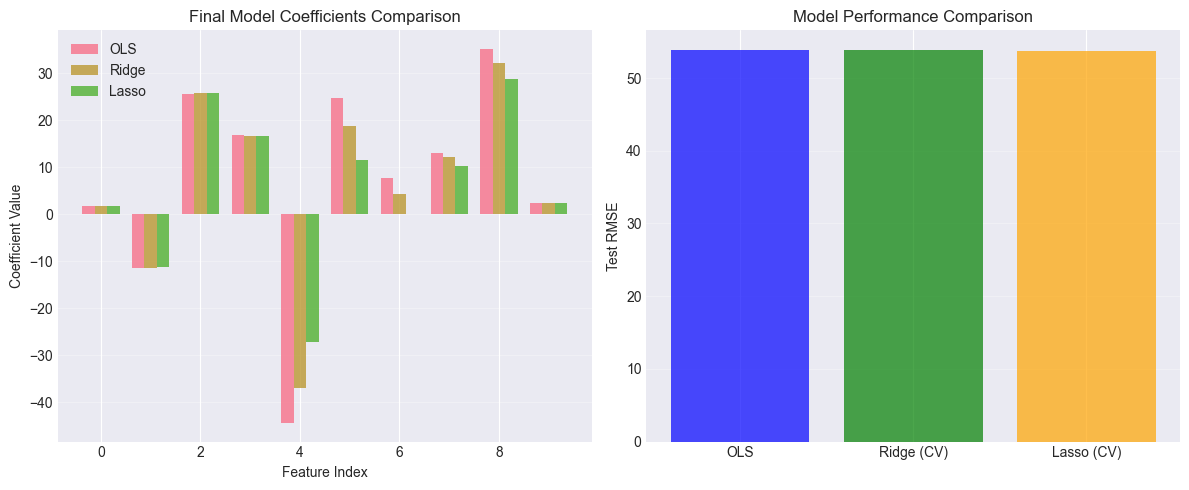

In [14]:
print("FINAL MODEL COMPARISON")

models = ['OLS', 'Ridge (CV)', 'Lasso (CV)']
test_rmses = [test_rmse_ols, test_rmse_ridge, test_rmse_lasso]
num_features = [len(ols_coef), len(ridge_best.coef_), np.sum(lasso_best.coef_ != 0)]

print("\nModel Performance Summary:")
print(f"{'Model':<15} {'Test RMSE':<12} {'R²':<10} {'Features':<10}")
print(f"{'OLS':<15} {test_rmse_ols:<12.4f} {test_r2_ols:<10.4f} {num_features[0]:<10}")
print(f"{'Ridge (CV)':<15} {test_rmse_ridge:<12.4f} {r2_score(y_test, y_test_pred_ridge):<10.4f} {num_features[1]:<10}")
print(f"{'Lasso (CV)':<15} {test_rmse_lasso:<12.4f} {r2_score(y_test, y_test_pred_lasso):<10.4f} {num_features[2]:<10}")

print(f"\nBest model: {models[np.argmin(test_rmses)]} (RMSE: {min(test_rmses):.4f})")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
x_pos = np.arange(len(ols_coef))
bar_width = 0.25
plt.bar(x_pos - bar_width, ols_coef, width=bar_width, label='OLS', alpha=0.8)
plt.bar(x_pos, ridge_best.coef_, width=bar_width, label='Ridge', alpha=0.8)
plt.bar(x_pos + bar_width, lasso_best.coef_, width=bar_width, label='Lasso', alpha=0.8)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Final Model Coefficients Comparison')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.bar(models, test_rmses, color=['blue', 'green', 'orange'], alpha=0.7)
plt.ylabel('Test RMSE')
plt.title('Model Performance Comparison')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()